In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("../")

In [3]:
import pandas as pd
from pathlib import Path

from phonetics import plots as plots

In [4]:
root = Path('/Users/tomasandrade/Documents/BSC/ICHOIR/datasets/IWSLT2024_Quechua_data/experiments')

In [5]:
experiment_path = root / 'iwslt_v1'
feat_path = experiment_path / 'feat_2d' / 'feat_2d_layer_8.csv'
tag_path = experiment_path / 'tag' / 'layer_8_phone_tags_libri_768d_v3.csv'

In [6]:
df_feat = pd.read_csv(feat_path, index_col=0)
df_tag = pd.read_csv(tag_path, index_col=0)

In [7]:
df_feat = df_feat.drop(columns=['phone_base', 'duration', 'start'])
df_feat = df_feat.join(df_tag)
df_feat = df_feat[~df_feat['phone_base'].isna()]

In [14]:
unique_phones = list(df_feat['phone_base'].value_counts().keys())

Making a 2d plot
<class 'list'>
['sp', 'AH', 'N', 'IY', 'T', 'K', 'EY', 'M', 'AY', 'IH', 'AE', 'D', 'S', 'EH', 'spn']
['sp', 'AH', 'N', 'IY', 'T', 'K', 'EY', 'M', 'AY', 'IH', 'AE', 'D', 'S', 'EH', 'spn']


/Users/tomasandrade/miniconda3/envs/ling_env/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/Users/tomasandrade/miniconda3/envs/ling_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


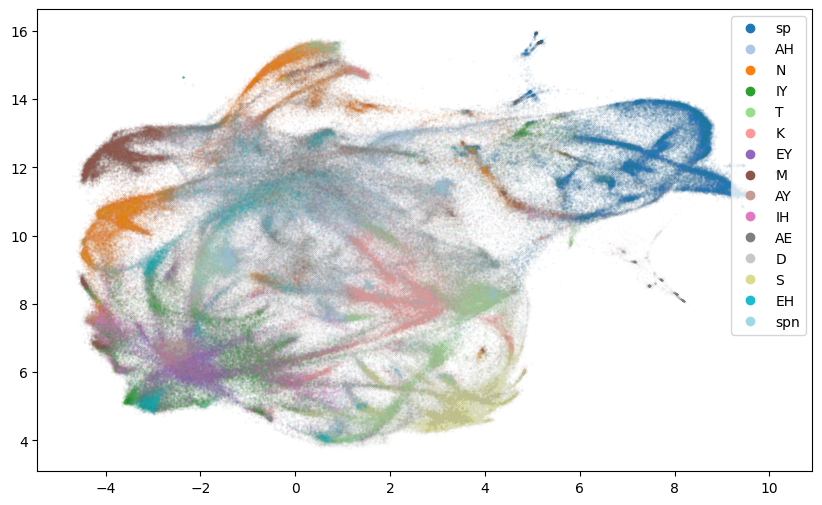

In [15]:
plots.make_tagged_LS_plot(df_feat,
            phones = unique_phones[:15],
            alpha = 0.1, 
            s = 0.1,
            show_global=True)

In [16]:
import datamapplot

In [20]:
plot = datamapplot.create_interactive_plot(
    df_feat[['x', 'y']].values,
    df_feat['phone_base'].values,
    hover_text = df_feat['phone_base'].values,
    font_family="Playfair Display SC",
    enable_search=False,
    darkmode=True
)
plot.save("quechua_8.html")